In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import scipy.stats as stats
import scipy.optimize
import numpy as np
import qng
import math
import matplotlib as mpl
import matplotlib.pyplot as plt

In [3]:
%matplotlib inline

In [4]:
stats.poisson.cdf(12,10.0)

0.79155647639487325

In [3]:
stats.poisson.ppf(0.95,10.0)

15.0

In [4]:
stats.poisson.cdf(15,10.0)

0.95125959669602123

In [5]:
range(1,5)

range(1, 5)

In [6]:
print(range(1,5))

range(1, 5)


In [10]:
for i in range(2,10):
    print (i)

2
3
4
5
6
7
8
9


In [8]:
import qng

In [9]:
qng.erlangB(5.0,6)

0.19184725888636478

In [10]:
qng.erlangB_rec(5.0,6)

0.19184725888636506

In [16]:
%timeit -n 10000 qng.erlangB(15.0,20)

10000 loops, best of 3: 354 µs per loop


In [17]:
%timeit -n 10000 qng.erlangB_rec(15.0,20)

10000 loops, best of 3: 5.06 µs per loop


In [20]:
%timeit -n 10000 qng.poissoninv(0.95,20)

10000 loops, best of 3: 241 µs per loop


In [3]:
arr_rate = 6
svc_rate = 3
c = 3
rho = arr_rate / (svc_rate * c)
load = arr_rate / svc_rate
print(arr_rate,svc_rate,c,rho,load)

6 3 3 0.6666666666666666 2.0


In [4]:
qng.mmc_prob_n(0, arr_rate, svc_rate, c)

0.1111111111111111

In [5]:
1/9

0.1111111111111111

In [3]:
pbar = np.ones(c)

In [4]:
for j in range(1,c):
    pbar[j] = arr_rate * pbar[j-1] / (j * svc_rate)

In [5]:
pbar

array([ 1.        ,  2.5       ,  3.125     ,  2.60416667])

In [6]:
sum(pbar)

9.2291666666666661

In [8]:
gamma = sum(pbar) + rho * pbar[c-1] / (1 - rho)
print(gamma)

13.5694444444


In [15]:
max(0,5)

5

In [6]:
qng.mmc_mean_qwait(arr_rate, svc_rate, c)

0.14814814814814811

In [7]:
arr_rate/(svc_rate * c)

0.6666666666666666

In [9]:
qng.mmc_waitq_cdf(0.14814814814814811,arr_rate, svc_rate, c)

0.71503093847557575

In [10]:
qng.mmc_waitq_cdf(0.5, arr_rate, svc_rate, c)

0.90083103993403124

In [11]:
p = -1
t = 0.1
p = qng.mmc_waitq_cdf(t, arr_rate, svc_rate, c)

while p < 0.95:
    p = qng.mmc_waitq_cdf(t, arr_rate, svc_rate, c)
    print(p,t)
    t = t + 0.1
    

0.670747457475 0.1
0.756083717292 0.2
0.819302373449 0.30000000000000004
0.866135905817 0.4
0.900831039934 0.5
0.926533827457 0.6
0.945574920776 0.7
0.959680909649 0.7999999999999999


In [12]:
p = -1
t = 0.7282
p = qng.mmc_waitq_cdf(t, arr_rate, svc_rate, c)

while p < 0.95:
    p = qng.mmc_waitq_cdf(t, arr_rate, svc_rate, c)
    print(p,t)
    t = t + 0.00001
    
    

0.949989896112 0.7282
0.949991396393 0.7282099999999999
0.949992896629 0.7282199999999999
0.949994396819 0.7282299999999998
0.949995896965 0.7282399999999998
0.949997397065 0.7282499999999997
0.949998897121 0.7282599999999997
0.950000397132 0.7282699999999996


In [13]:
def find_pctile(t, p, arr_rate, svc_rate, c):
    return qng.mmc_waitq_cdf(t, arr_rate, svc_rate, c) - p

In [14]:
p = 0.95
scipy.optimize.newton(find_pctile,0.5,args=(p, arr_rate, svc_rate, c))

0.72826735244588692

In [15]:
qng.mmc_waitq_pctile(p,arr_rate, svc_rate, c)

0.72826735244589413

In [22]:
qng.mm1_waitq_cdf(1.0,barber_arr, barber_svc)

0.693433799023798

In [25]:
qng.mmc_waitq_cdf(1.0,barber_arr, barber_svc, barber_c)

0.69343379902379798

In [17]:
qng.mmc_waitq_pctile(p,arr_rate, c * svc_rate, 1)

0.86342238848194153

In [18]:
barber_arr = 5
barber_svc = 6
barber_c = 1

In [20]:
qng.mmc_mean_qsize(barber_arr, barber_svc, barber_c)

4.1666666666666679

In [23]:
qng.mm1_waitq_pctile(0.9,barber_arr, barber_svc)

2.1202635362000914

In [24]:
qng.mm1_waitq_cdf(2.1202635362000914,barber_arr, barber_svc)

0.9

In [28]:
5/6 * math.exp(-1.0)

0.30656620097620196

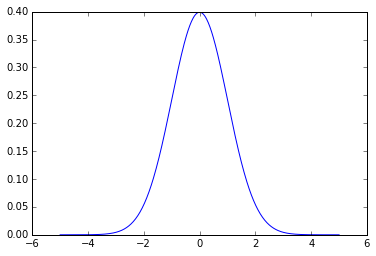

In [7]:
x = np.linspace(-5, 5, 500)
plt.plot(x, stats.norm.pdf(x))

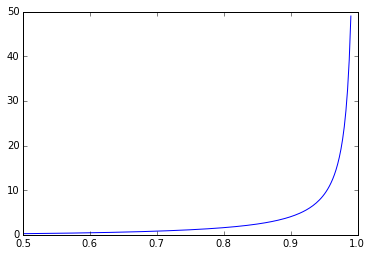

In [4]:
rho = np.linspace(0.5, .99, 200)
plt.plot(rho, qng.mg1_mean_qsize(rho,1,1))

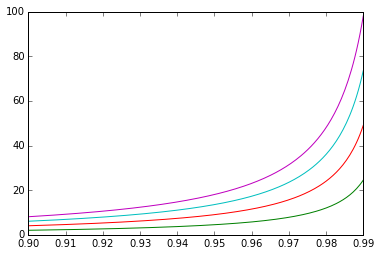

In [16]:
rho = np.linspace(0.9, .99, 200)
for cv2 in np.linspace(0, 2, 5):
    plt.plot(rho, qng.mg1_mean_qsize(rho,1,cv2))

In [9]:
rho = np.linspace(0.5, .99, 200)
load = rho * 2
qsize = [qng.mmc_mean_qsize(l, 1, 2) for l in load]

In [7]:
load

array([ 1.        ,  1.00492462,  1.00984925,  1.01477387,  1.01969849,
        1.02462312,  1.02954774,  1.03447236,  1.03939698,  1.04432161,
        1.04924623,  1.05417085,  1.05909548,  1.0640201 ,  1.06894472,
        1.07386935,  1.07879397,  1.08371859,  1.08864322,  1.09356784,
        1.09849246,  1.10341709,  1.10834171,  1.11326633,  1.11819095,
        1.12311558,  1.1280402 ,  1.13296482,  1.13788945,  1.14281407,
        1.14773869,  1.15266332,  1.15758794,  1.16251256,  1.16743719,
        1.17236181,  1.17728643,  1.18221106,  1.18713568,  1.1920603 ,
        1.19698492,  1.20190955,  1.20683417,  1.21175879,  1.21668342,
        1.22160804,  1.22653266,  1.23145729,  1.23638191,  1.24130653,
        1.24623116,  1.25115578,  1.2560804 ,  1.26100503,  1.26592965,
        1.27085427,  1.27577889,  1.28070352,  1.28562814,  1.29055276,
        1.29547739,  1.30040201,  1.30532663,  1.31025126,  1.31517588,
        1.3201005 ,  1.32502513,  1.32994975,  1.33487437,  1.33

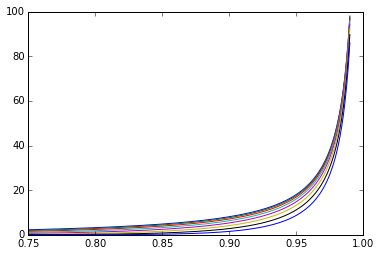

In [11]:
rho = np.linspace(0.75, .99, 200)
for c in [1, 2, 4, 8, 16, 32, 64, 128]:
    load = rho * c
    qsize = [qng.mmc_mean_qsize(l, 1, c) for l in load]
    plt.plot(rho, qsize)

# Debugging Whitt's GI/G/m code

In [3]:
# D/M/m from Table2 - SEEMS TO BE OVERESTIMATING. ONLY WORKING NOW BECAUSE I KLUDGED IN
# A TRAP FOR THE D/M/m CASE AND CALL A FUNCTION FOR THAT CASE THAT IMPLEMENTS EQ 2.20 OF WHITT.
rho = 0.80
m = 4
lam = rho * m
tablevalue = 0.87
print(qng.ggm_mean_qwait_whitt(rho * m, 1.0, m, 0, 1) * lam, tablevalue)

rho = 0.80
m = 8
lam = rho * m
tablevalue = 0.58
print(qng.ggm_mean_qwait_whitt(rho * m, 1.0, m, 0, 1) * lam, tablevalue)

0.872525367112 0.87
0.57846270743 0.58


In [4]:
# D/M/m from Table2 but using 2.20 - SEE COMMENT ABOVE FOR ONLY REASON THESE TWO MATCH NOW
rho = 0.8
m = 4
lam = rho * m

print(qng.dmm_mean_qwait_whitt(rho * m, 1.0, m, 0, 1) * lam)
print(qng.ggm_mean_qwait_whitt(rho * m, 1.0, m, 0, 1) * lam)

0.872525367112
0.872525367112


So, why do these two methods give different answers? I'm matching the values in Table 2 using 2.20.

Does Eq 2.24 reduce to 2.20 for the D/M/m case? It boils down to whether phi_0 reduces to phi_3?

Below, it seems that 2.16 for M/D/m gives same results as 2.24. 

According to Whitt (1993), bottom of p125, yes indeed, 2.24 is consistent with 2.16 when cs2=0 and with 2.20 when ca2=0. THEREFORE I MUST HAVE AN ERROR IN MY PHI_0 FOR THE SECOND CASE OF 2.25 (ca2 < cs2)

In [7]:
# Phi_0 should equal Phi_3 for M/D/m - it does NOT. Since the dmm function is working, it would seem that phi_0 
# is the culprit. Case 2.
rho = 0.8
m = 4
print(qng.phi_0(rho, 0 , 1, m), qng.phi_3(m, rho))

0.80708331013629 0.7314536082328932


In [8]:
# For DMm, psi_0 must equal phi_3 since phi = (1/2)phi_3 + (1/2)psi_0
# Furthermore, phi_3 appears correct since i can match Table 2 via Eq 2.20 which uses phi_3 directly
print(qng.psi_0(0.5,m,rho), qng.phi_3(m,rho), qng.phi_3(m,rho) / qng.psi_0(0.5,m,rho))

0.8827130120396869 0.7314536082328932 0.8286426032654959


In [9]:
qng.phi_4(m,rho)

0.8827130120396869

In [48]:
qng.phi_4(m,rho) ** 1.5

0.8293336608905804

In [34]:
# Phi_0 should equal Phi_1 for M/D/m - it does
rho = 0.95
m = 30
print(qng.phi_0(rho, 1 , 0, m), qng.phi_1(m, rho))

1.0331009359357166 1.0331009359357166


In [16]:
print("gamma: ", qng.gamma_0(4, .8))
print("ph1_1: ", qng.phi_1(4, .8))
print("ph1_2: ", qng.phi_2(4, .8))
print("ph1_3: ", qng.phi_3(4, .8))
print("ph1_4: ", qng.phi_4(4, .8))
qng.phi_2(4, .8) * math.exp(-2 * (1-0.8)/(3*0.8))

gamma:  0.03397241584648072
ph1_1:  1.0339724158464807
ph1_2:  0.8641103366140771
ph1_3:  0.7314536082328932
ph1_4:  0.8827130120396869


0.7314536082328932

In [17]:
1-4*(0.034)

0.864

In [18]:
(1-0.8)*(4-1)*(((4+5*4)**0.5)-2)/(16 * 4 * 0.8)

0.03397241584648072

In [19]:
0.864 * math.exp(-2*(1-0.8)/(3 * 0.8))

0.7313602103054906

In [24]:
# M/D/m from Table 3 - SEEMS TO BE WORKING FOR M/D/m
# should be 0.53
print(qng.ggm_mean_qwait_whitt(0.7 * 4, 1.0, 4, 1, 0) * 0.7 * 4)
print(qng.mdm_mean_qwait_whitt(0.7 * 4, 1.0, 4, 1, 0) * 0.7 * 4)

# should be 2.61
rho = 0.90
m = 20
lam = rho * m
tablevalue = 2.61
print(qng.ggm_mean_qwait_whitt(rho * m, 1.0, m, 1, 0) * lam)
print(qng.mdm_mean_qwait_whitt(rho * m, 1.0, m, 1, 0) * lam)

0.529221550111
0.529221550111
2.6125062875
2.6125062875


In [36]:
# M/D/m from Table 3 - 
# should be 1.44
rho = 0.8
m = 2
lam = rho * m
qng.ggm_mean_qwait_whitt(rho * m, 1.0, m, 1, 0) * lam

1.4415739709641553

In [37]:
# h2/M/m from Table 4 - - SEEMS TO BE WORKING FOR M/D/m
ca2 = 2.25
rho = 0.5
m = 2
lam = rho * m
qng.ggm_mean_qwait_whitt(rho * m, 1.0, m, ca2, 1) * lam

0.56623431643669841

In [5]:
# E4/M/m from Table5 - SEEMS TO BE WORKING
rho = 0.8
m = 2
lam = rho * m
tablevalue = 1.58
print(qng.ggm_mean_qwait_whitt(rho * m, 1.0, m, 0.25, 1) * lam, tablevalue)

tablevalue = 3.58
print(qng.ggm_mean_qwait_whitt(0.9 * 8, 1.0, 8, 0.25, 1) * 0.9 * 8, tablevalue)

tablevalue = 8.4
print(qng.ggm_mean_qwait_whitt(0.95 * 20, 1.0, 20, 0.25, 1) * 0.95 * 20, tablevalue)

tablevalue = 1.28
print(qng.ggm_mean_qwait_whitt(0.8 * 4, 1.0, 4, 0.25, 1) * 0.8 * 4, tablevalue)

1.58348787833 1.58
3.58322523059 3.58
8.35574110007 8.4
1.27772295628 1.28


In [6]:
.5 * .7313 / .8827 

0.4142403987764812